# Tangent Correlations of Random-Wave Lines

This notebook calculates the line-density-weighted signed correlation $K_T^{\rm raw}(r)$ and nematic correlation $K_2(r)$ for an isotropic random-wave line ensemble. The spectrum, radial grid, and conditional Gaussian sampling parameters match `rw_line_general.ipynb`. Both quantities are total correlations; separating same-component and different-component contributions requires connected-component tracing.

In [1]:
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import rw_line_scattering as ris
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "grid.alpha": 0.25})

## Random-wave spectrum

In [2]:
k0_nominal = 1.0
k_distribution = "gaussian_radial"
num_modes_k = 2**13
k_distribution_params = {"r_sigma_k": 0.4}
r_sigma_k = k_distribution_params["r_sigma_k"]
random_seed = 12345
k_sampling = "qmc"

if k_sampling == "quadrature":
    k_radii, k_weights = ris.make_radial_k_quadrature(num_modes_k, k_distribution, k0=k0_nominal, sigma_k=r_sigma_k*k0_nominal, distribution_params=k_distribution_params)
else:
    k_rng = np.random.default_rng(random_seed)
    k_sets = ris.make_field_k_sets(num_modes_k, k_distribution, k_rng, k0=k0_nominal, r_sigma_k=r_sigma_k, distribution_params=k_distribution_params, shared_k_vectors=True, use_qmc_k=(k_sampling == "qmc"), qmc_seed=random_seed)
    k_radii = ris.k_radii_from_vectors(k_sets.psi1)
    k_weights = None

a = ris.gradient_variance_from_k_radii(k_radii, k_weights=k_weights)
rho0 = ris.rho0_from_k_radii(k_radii, k_weights=k_weights)
k_eff = np.sqrt(3*a)
print(f"distribution={k_distribution}; sampling={k_sampling}; k_eff={k_eff:.12g}; rho0={rho0:.12g}")

distribution=gaussian_radial; sampling=qmc; k_eff=1.08035234902; rho0=0.123839649367


## Separation grid and unsigned Jacobian moment

In [3]:
r_min = 1e-3 / k_eff
r_max = 250 / k_eff
r_split = 5.0 / k_eff
Nr = 1000
Nr_small = 200
r_grid = ris.make_r_grid(r_min, r_max, Nr, mode="mixed", r_split=r_split, n_small=Nr_small)

N_samp = 2**15
use_qmc = True
jacobian_method = "direct_12d"
N_samp_U = N_samp
N_samp_st = 2**8
U_sampling = "qmc" if use_qmc else "random"
st_sampling = "quadrature"
st_transform = "rational"

M_J, C_L = ris.compute_CL_general(r_grid, k_radii, N_samp, k_weights=k_weights, use_qmc=use_qmc, random_seed=random_seed, progress=True, jacobian_method=jacobian_method, N_samp_U=N_samp_U, N_samp_st=N_samp_st, U_sampling=U_sampling, st_sampling=st_sampling, st_transform=st_transform)

M_J direct_12d: 50/1001 r values (0.5s)
M_J direct_12d: 100/1001 r values (0.9s)
M_J direct_12d: 150/1001 r values (1.3s)
M_J direct_12d: 200/1001 r values (1.7s)
M_J direct_12d: 250/1001 r values (2.1s)
M_J direct_12d: 300/1001 r values (2.5s)
M_J direct_12d: 350/1001 r values (2.9s)
M_J direct_12d: 400/1001 r values (3.2s)
M_J direct_12d: 450/1001 r values (3.6s)
M_J direct_12d: 500/1001 r values (3.9s)
M_J direct_12d: 550/1001 r values (4.3s)
M_J direct_12d: 600/1001 r values (4.7s)
M_J direct_12d: 650/1001 r values (5.1s)
M_J direct_12d: 700/1001 r values (5.5s)
M_J direct_12d: 750/1001 r values (6.0s)
M_J direct_12d: 800/1001 r values (6.5s)
M_J direct_12d: 850/1001 r values (7.0s)
M_J direct_12d: 900/1001 r values (7.5s)
M_J direct_12d: 950/1001 r values (8.0s)
M_J direct_12d: 1000/1001 r values (8.4s)
M_J direct_12d: 1001/1001 r values (8.4s)


## Exact signed tangent correlation

For separation along $\hat z$, $b=-g'/r$ and $c_z=-g''-g(g')^2/(1-g^2)$. Wick contraction gives $M_T=2b^2+4bc_z$ and hence $K_T^{\rm raw}=M_T/M_J$.

In [4]:
tcorr = ris.compute_signed_tangent_correlation(r_grid, k_radii, M_J, k_weights=k_weights)
g, gp, gpp = tcorr["g"], tcorr["gp"], tcorr["gpp"]
b, c_z = tcorr["b"], tcorr["c_z"]
M_T, K_T_raw = tcorr["M_T"], tcorr["K_T_raw"]
N_T_raw = ris.pzeros_self_from_g(g)**2 * M_T
print(f"K_T_raw(r_min) = {K_T_raw[0]:.12g}")
print("Expected limit as r approaches zero: 1")
print(f"max |N_T_raw/C_L - K_T_raw| = {np.nanmax(np.abs(N_T_raw/C_L-K_T_raw)):.3e}")

K_T_raw(r_min) = 0.998839624
Expected limit as r approaches zero: 1
max |N_T_raw/C_L - K_T_raw| = 3.331e-16


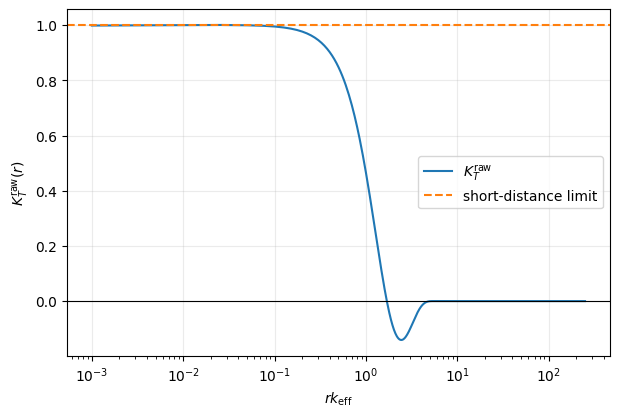

In [5]:
fig, ax = plt.subplots()
ax.semilogx(r_grid*k_eff, K_T_raw, label=r"$K_T^{\rm raw}$")
ax.axhline(0, color="black", lw=0.8)
ax.axhline(1, color="tab:orange", ls="--", label="short-distance limit")
ax.set_xlabel(r"$r k_{\rm eff}$")
ax.set_ylabel(r"$K_T^{\rm raw}(r)$")
ax.legend()
plt.show()

## Line-density-weighted nematic correlation

The nematic statistic is $K_2=M_2/M_J=\sum_m w_mP_2(\mu_m)/\sum_mw_m$, with $w_m=|\boldsymbol\omega_0||\boldsymbol\omega_r|$ and $P_2(\mu)=(3\mu^2-1)/2$. The numerator and denominator use the same conditional Gaussian samples.

In [6]:
nematic = ris.compute_nematic_tangent_correlation(r_grid, k_radii, N_samp, k_weights=k_weights, use_qmc=use_qmc, random_seed=random_seed, progress=True)
M_J_nematic = nematic["M_J"]
M_2 = nematic["M_2"]
K_2 = nematic["K_2"]
K_2_inf_sampled = nematic["K_2_inf_sampled"]
N_2 = ris.pzeros_self_from_g(g)**2 * M_2
print(f"K_2(r_min) = {K_2[0]:.12g}")
print(f"K_2_inf_sampled = {K_2_inf_sampled:.12g}")
print("Expected limit as r approaches zero: 1")
print(f"max |M_J_nematic/M_J - 1| = {np.nanmax(np.abs(M_J_nematic/M_J-1)):.3e}")
print(f"max |N_2/C_L - K_2| = {np.nanmax(np.abs(N_2/C_L-K_2)):.3e}")

K_2 direct_12d: 50/1001 r values (0.4s)
K_2 direct_12d: 100/1001 r values (0.8s)
K_2 direct_12d: 150/1001 r values (1.2s)
K_2 direct_12d: 200/1001 r values (1.6s)
K_2 direct_12d: 250/1001 r values (2.0s)
K_2 direct_12d: 300/1001 r values (2.4s)
K_2 direct_12d: 350/1001 r values (2.8s)
K_2 direct_12d: 400/1001 r values (3.1s)
K_2 direct_12d: 450/1001 r values (3.5s)
K_2 direct_12d: 500/1001 r values (3.9s)
K_2 direct_12d: 550/1001 r values (4.2s)
K_2 direct_12d: 600/1001 r values (4.6s)
K_2 direct_12d: 650/1001 r values (5.0s)
K_2 direct_12d: 700/1001 r values (5.4s)
K_2 direct_12d: 750/1001 r values (5.9s)
K_2 direct_12d: 800/1001 r values (6.4s)
K_2 direct_12d: 850/1001 r values (6.8s)
K_2 direct_12d: 900/1001 r values (7.2s)
K_2 direct_12d: 950/1001 r values (7.7s)
K_2 direct_12d: 1000/1001 r values (8.1s)
K_2 direct_12d: 1001/1001 r values (8.1s)
K_2(r_min) = 0.999998296992
K_2_inf_sampled = 0.00299532912235
Expected limit as r approaches zero: 1
max |M_J_nematic/M_J - 1| = 0.000e+0

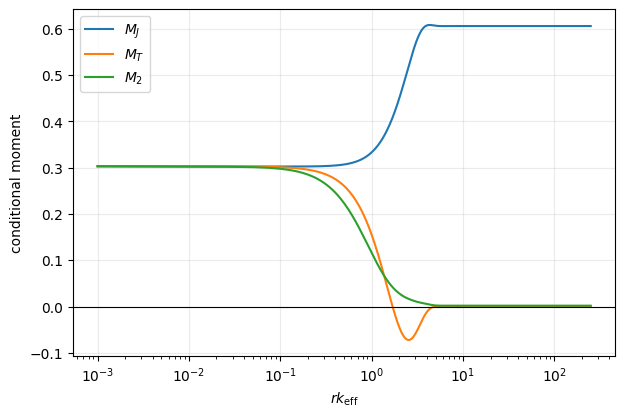

In [7]:
fig, ax = plt.subplots()
ax.semilogx(r_grid*k_eff, M_J, label=r"$M_J$")
ax.semilogx(r_grid*k_eff, M_T, label=r"$M_T$")
ax.semilogx(r_grid*k_eff, M_2, label=r"$M_2$")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel(r"$r k_{\rm eff}$")
ax.set_ylabel("conditional moment")
ax.legend()
plt.show()

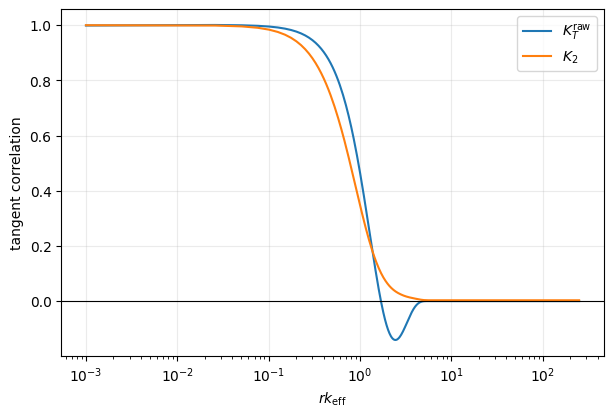

In [8]:
fig, ax = plt.subplots()
ax.semilogx(r_grid*k_eff, K_T_raw, label=r"$K_T^{\rm raw}$")
ax.semilogx(r_grid*k_eff, K_2, label=r"$K_2$")
ax.axhline(0, color="black", lw=0.8)
# ax.axhline(1, color="tab:orange", ls="--", label="short-distance limit")
ax.set_xlabel(r"$r k_{\rm eff}$")
ax.set_ylabel("tangent correlation")
ax.legend()
plt.show()

## Save data

The saved results include the field-imposed signed correlation and the orientation-reversal-invariant total nematic correlation. Separating either statistic into intra- and intercomponent contributions still requires connected-component labels from line tracing.

In [9]:
output_dir = Path("rw_line_tcorr_output")
output_dir.mkdir(exist_ok=True)
np.savez(output_dir / "tangent_correlation_data.npz", r_grid=r_grid, k_radii=k_radii, k_weights=k_weights, g=g, gp=gp, gpp=gpp, b=b, c_z=c_z, M_J=M_J, M_T=M_T, M_2=M_2, C_L=C_L, N_T_raw=N_T_raw, N_2=N_2, K_T_raw=K_T_raw, K_2=K_2, K_2_inf_sampled=K_2_inf_sampled, k0_nominal=k0_nominal, k_eff=k_eff, a=a, rho0=rho0, k_distribution=k_distribution, k_sampling=k_sampling, r_sigma_k=r_sigma_k, N_samp=N_samp, jacobian_method=jacobian_method, random_seed=random_seed)
print(f"saved data to {output_dir.resolve()}")

saved data to C:\Users\ccu\Documents\codex_projects\project_randomcxl\smpl\rw_line_tcorr_output
